In [22]:
import tensorflow as tf

tf.__version__

'2.19.0'

In [23]:
dataset_url = "https://storage.googleapis.com/download.tensorflow.org/example_images/flower_photos.tgz"

data_dir = tf.keras.utils.get_file('flower_photos.tar', origin=dataset_url, extract=True, cache_dir=".")

In [24]:
from pathlib import Path

data_dir = Path(data_dir)
data_dir = data_dir/"flower_photos"

In [25]:
data_dir

PosixPath('datasets/flower_photos_extracted/flower_photos')

In [26]:
batch_size = 32
img_height = 180
img_width = 180


In [27]:
train_ds = tf.keras.utils.image_dataset_from_directory(data_dir, 
                                                       validation_split=0.2, 
                                                       subset="training", seed=42, 
                                                       image_size=(img_height,img_width),
                                                       batch_size=batch_size)

val_ds = tf.keras.utils.image_dataset_from_directory(data_dir, 
                                                       validation_split=0.2, 
                                                       subset="validation", seed=42, 
                                                       image_size=(img_height,img_width),
                                                       batch_size=batch_size)

Found 3670 files belonging to 5 classes.
Using 2936 files for training.
Found 3670 files belonging to 5 classes.
Using 734 files for validation.


In [28]:
class_names = train_ds.class_names

2025-06-25 19:04:23.530324: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


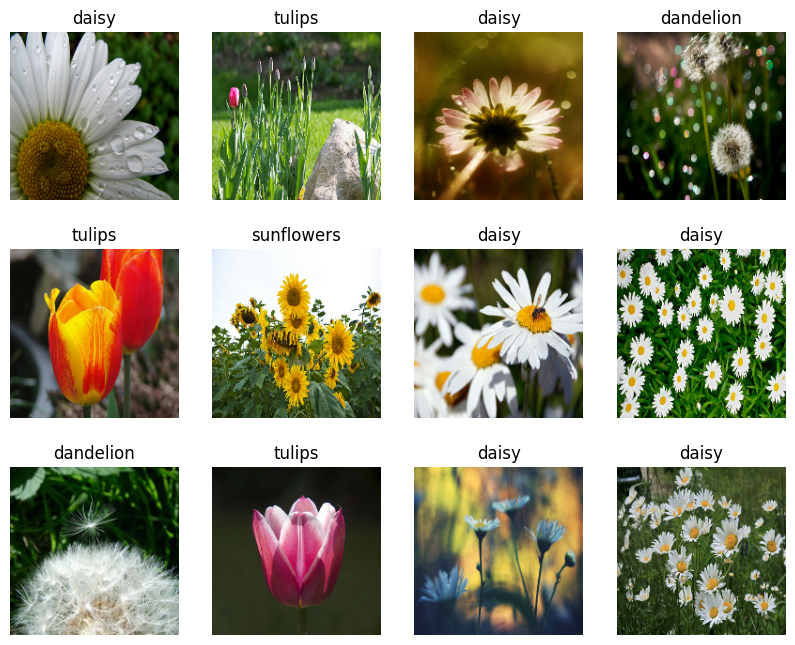

In [29]:
## Visualize the image
import matplotlib.pyplot as plt 
plt.figure(figsize=(10,8))
for image, label in train_ds.take(1):
    for i in range(12):
        plt.subplot(3,4,i+1)
        plt.imshow(image[i]/ 255.0)
        plt.title(train_ds.class_names[label[i]])
        plt.axis("off")


In [30]:
AUTOTUNE = tf.data.AUTOTUNE
AUTOTUNE

train_ds = train_ds.cache().shuffle(10000).prefetch(buffer_size= AUTOTUNE)
val_ds = val_ds.cache().prefetch(buffer_size=AUTOTUNE)


In [34]:
num_of_classes = len(class_names)

In [35]:
from tensorflow.keras import layers, losses, optimizers, Sequential

model = Sequential([
    tf.keras.Input(shape=(180,180,3)),
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3 , activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3 , activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3 , activation="relu"),
    layers.MaxPooling2D(),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_of_classes)
])

In [36]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ rescaling (Rescaling)           │ (None, 180, 180, 3)    │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d (Conv2D)                 │ (None, 178, 178, 16)   │           448 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 89, 89, 16)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 87, 87, 32)     │         4,640 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 43, 43, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_2 (Conv2D)               │ (None, 41, 41, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_2 (MaxPooling2D)  │ (None, 20, 20, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 25600)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 128)            │     3,276,928 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 5)              │           645 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 3,301,157 (12.59 MB)

 Trainable params: 3,301,157 (12.59 MB)

 Non-trainable params: 0 (0.00 B)

In [38]:
model.compile(loss=losses.SparseCategoricalCrossentropy(from_logits=True), optimizer=optimizers.Adam(learning_rate=1e-3), metrics=["accuracy"])

In [39]:
epochs = 10

history = model.fit(train_ds, validation_data=val_ds, epochs=epochs, )

Epoch 1/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 112ms/step - accuracy: 0.3465 - loss: 1.5712 - val_accuracy: 0.5572 - val_loss: 1.0587
Epoch 2/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 109ms/step - accuracy: 0.5996 - loss: 1.0178 - val_accuracy: 0.6090 - val_loss: 0.9750
Epoch 3/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 112ms/step - accuracy: 0.6928 - loss: 0.8010 - val_accuracy: 0.6417 - val_loss: 0.9454
Epoch 4/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 10s 113ms/step - accuracy: 0.8210 - loss: 0.5408 - val_accuracy: 0.6172 - val_loss: 1.0837
Epoch 5/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 115ms/step - accuracy: 0.8739 - loss: 0.3517 - val_accuracy: 0.6322 - val_loss: 1.2812
Epoch 6/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 117ms/step - accuracy: 0.9325 - loss: 0.2007 - val_accuracy: 0.6240 - val_loss: 1.5355
Epoch 7/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 120ms/step - accuracy: 0.9719 - loss: 0.1102 - val_accuracy: 0.6322 - val_loss: 1.7442
Epoch 8/10
92/92 ━━━━━━━━━━━━━━━━━━━━ 11s 121ms/step - accuracy: 0.9818 - loss: 0.0751 - val_accu

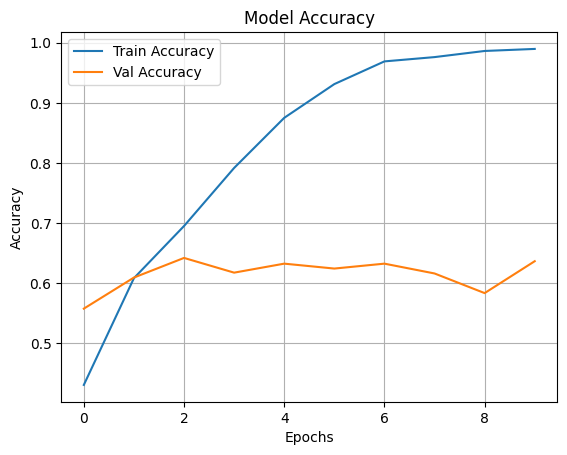

In [61]:
# plot the metrcis

plt.plot(history.history["accuracy"], label="Train Accuracy")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")

plt.plot(history.history["val_accuracy"],  label="Val Accuracy")
plt.grid()
plt.title("Model Accuracy")

plt.legend()
plt.show()



In [89]:
# create a data augmentation:  if you have low training samples
data_augmentation= Sequential([
    tf.keras.Input(shape=(img_height, img_width, 3)),
    layers.RandomFlip("horizontal"),
    layers.RandomRotation(factor=0.1),
    layers.RandomZoom(0.1)

])

2025-06-25 19:41:19.361128: I tensorflow/core/framework/local_rendezvous.cc:407] Local rendezvous is aborting with status: OUT_OF_RANGE: End of sequence


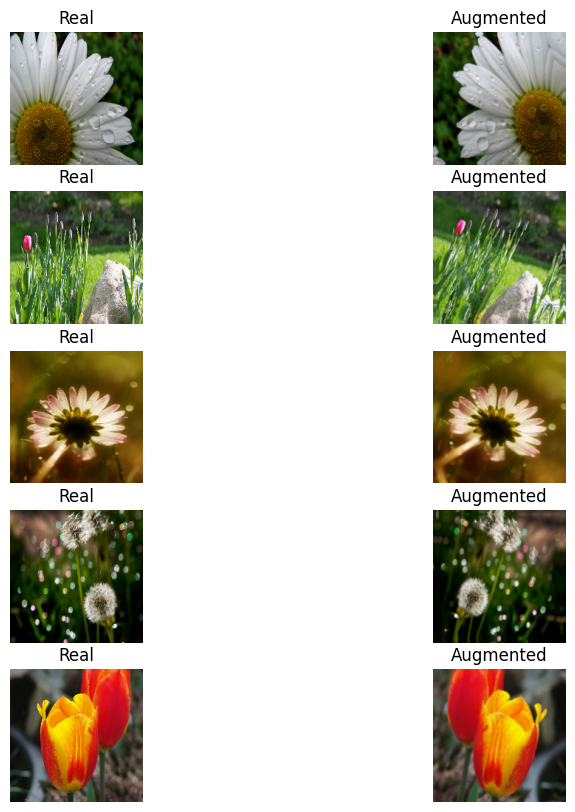

In [82]:
## Visualizs the augmented image
plt.figure(figsize=(10,10))
for img, label in train_ds.take(1):
    for i in range(5):
        plt.subplot(5,2,2*i+1)
        plt.imshow(image[i]/255.0)
        plt.title("Real")
        plt.axis("off")

        plt.subplot(5,2,2*i+2)
        plt.imshow(data_augmentation(image[i]/255.0))
        plt.title("Augmented")
        plt.axis("off")
        

In [93]:
model = Sequential([
    data_augmentation,
    layers.Rescaling(1./255),
    layers.Conv2D(16, 3 , activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(32, 3 , activation="relu"),
    layers.MaxPooling2D(),
    layers.Conv2D(64, 3 , activation="relu"),
    layers.MaxPooling2D(),
    layers.Dropout(0.2),
    layers.Flatten(),
    layers.Dense(128, activation="relu"),
    layers.Dense(num_of_classes)
])

In [94]:
model.compile(optimizer='adam',
              loss=tf.keras.losses.SparseCategoricalCrossentropy(from_logits=True),
              metrics=['accuracy'])

In [95]:
epochs = 15
history = model.fit(
  train_ds,
  validation_data=val_ds,
  epochs=epochs
)

Epoch 1/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.3735 - loss: 1.3969 - val_accuracy: 0.4646 - val_loss: 1.4198
Epoch 2/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 127ms/step - accuracy: 0.5796 - loss: 1.0709 - val_accuracy: 0.5967 - val_loss: 1.0732
Epoch 3/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 12s 130ms/step - accuracy: 0.6309 - loss: 0.9742 - val_accuracy: 0.6390 - val_loss: 0.9604
Epoch 4/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 137ms/step - accuracy: 0.6605 - loss: 0.8559 - val_accuracy: 0.6608 - val_loss: 0.9281
Epoch 5/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 139ms/step - accuracy: 0.6884 - loss: 0.8078 - val_accuracy: 0.6839 - val_loss: 0.8448
Epoch 6/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - accuracy: 0.6946 - loss: 0.7786 - val_accuracy: 0.6921 - val_loss: 0.8344
Epoch 7/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 144ms/step - accuracy: 0.7230 - loss: 0.7176 - val_accuracy: 0.6975 - val_loss: 0.8663
Epoch 8/15
92/92 ━━━━━━━━━━━━━━━━━━━━ 13s 143ms/step - accuracy: 0.7349 - loss: 0.6941 - val_accu

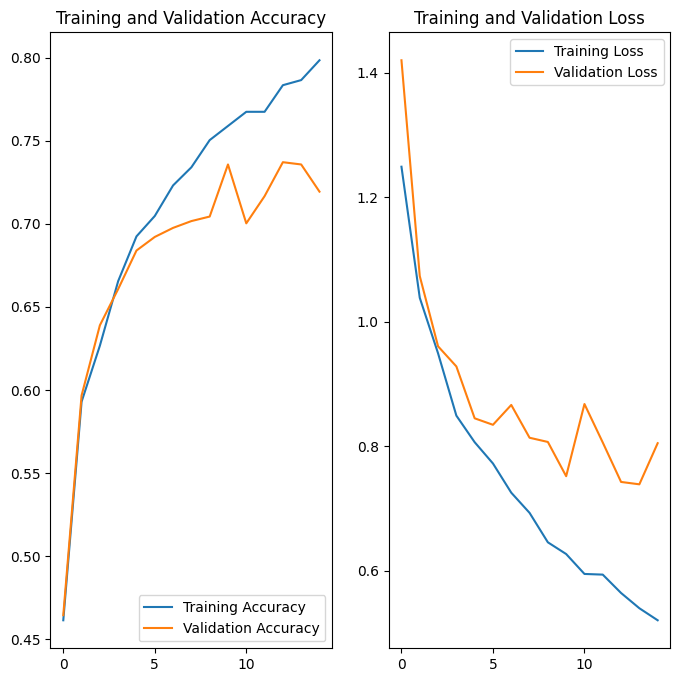

In [96]:
acc = history.history['accuracy']
val_acc = history.history['val_accuracy']

loss = history.history['loss']
val_loss = history.history['val_loss']

epochs_range = range(epochs)

plt.figure(figsize=(8, 8))
plt.subplot(1, 2, 1)
plt.plot(epochs_range, acc, label='Training Accuracy')
plt.plot(epochs_range, val_acc, label='Validation Accuracy')
plt.legend(loc='lower right')
plt.title('Training and Validation Accuracy')

plt.subplot(1, 2, 2)
plt.plot(epochs_range, loss, label='Training Loss')
plt.plot(epochs_range, val_loss, label='Validation Loss')
plt.legend(loc='upper right')
plt.title('Training and Validation Loss')
plt.show()

In [108]:

import numpy as np
sunflower_url = "https://www.bakeshake.co.in/image/cache/catalog/products/red%20artificial%20flowers%201-800x800.jpg"
sunflower_path = tf.keras.utils.get_file('Red_sunflower', origin=sunflower_url, cache_dir=".", force_download=True)

img = tf.keras.utils.load_img(
    sunflower_path, target_size=(img_height, img_width)
)
img_array = tf.keras.utils.img_to_array(img)
img_array = tf.expand_dims(img_array, 0) # Create a batch

predictions = model.predict(img_array)
score = tf.nn.softmax(predictions[0])

print(
    "This image most likely belongs to {} with a {:.2f} percent confidence."
    .format(class_names[np.argmax(score)], 100 * np.max(score))
)

81854/81854 ━━━━━━━━━━━━━━━━━━━━ 0s 1us/step
1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 19ms/step
This image most likely belongs to roses with a 94.12 percent confidence.
